# Round 1 Visualisation
Load round 1 prices and trades, stitch day `-2`, `-1`, and `0` into one continuous timeline, detect zero-price anomalies from empty books, infer trade side from the latest book snapshot, and plot cleaned prices, trades, price changes, and ash coated osmium volatility.


In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

DAY_ORDER = [-2, -1, 0]
DAY_LENGTH = 1_000_000
DAY_STARTS = {day: index * DAY_LENGTH for index, day in enumerate(DAY_ORDER)}
DAY_BOUNDARIES = {day: DAY_STARTS[day] for day in DAY_ORDER[1:]}
PRODUCTS = ["ASH_COATED_OSMIUM", "INTARIAN_PEPPER_ROOT"]
PRODUCT_LABELS = {
    "ASH_COATED_OSMIUM": "Ash Coated Osmium",
    "INTARIAN_PEPPER_ROOT": "Intarian Pepper Root",
}
PRODUCT_COLORS = {
    "ASH_COATED_OSMIUM": "#1f77b4",
    "INTARIAN_PEPPER_ROOT": "#ff7f0e",
}
TRADE_SIDE_COLORS = {
    "Buy": "#2ca02c",
    "Sell": "#d62728",
    "Unknown": "#7f7f7f",
}
ASH_OSMIUM_MEAN = 10_000
ASH_OSMIUM_VOLATILITY_LOOKBACKS = [25, 50, 100, 250]

round1_candidates = [
    Path.cwd() / "backtester/prosperity4bt/resources/round1",
    Path.cwd() / "../backtester/prosperity4bt/resources/round1",
]
ROUND1_DIR = next((path.resolve() for path in round1_candidates if path.exists()), None)
if ROUND1_DIR is None:
    raise FileNotFoundError("Could not find backtester/prosperity4bt/resources/round1 from the current notebook working directory.")


def add_day_markers(ax):
    for day, boundary in DAY_BOUNDARIES.items():
        ax.axvline(boundary, color="0.35", linestyle="--", linewidth=1)
        ax.text(
            boundary + DAY_LENGTH * 0.01,
            0.98,
            f"day {day} begins",
            transform=ax.get_xaxis_transform(),
            ha="left",
            va="top",
            fontsize=9,
            color="0.35",
        )

    ax.set_xticks([DAY_STARTS[day] + DAY_LENGTH / 2 for day in DAY_ORDER])
    ax.set_xticklabels([f"day {day}" for day in DAY_ORDER])


ROUND1_DIR


PosixPath('/home/sean/projects/prosperity-4/backtester/prosperity4bt/resources/round1')

In [10]:
def load_prices(day: int) -> pd.DataFrame:
    frame = pd.read_csv(ROUND1_DIR / f"prices_round_1_day_{day}.csv", sep=";")
    frame["day"] = day
    frame["stitched_timestamp"] = frame["timestamp"] + DAY_STARTS[day]
    return frame


def load_trades(day: int) -> pd.DataFrame:
    frame = pd.read_csv(ROUND1_DIR / f"trades_round_1_day_{day}.csv", sep=";")
    frame = frame.rename(columns={"symbol": "product"})
    frame["day"] = day
    frame["stitched_timestamp"] = frame["timestamp"] + DAY_STARTS[day]
    return frame


def rolling_rms_distance_from_mean(series: pd.Series, mean: float, window: int) -> pd.Series:
    valid = series.dropna()
    squared_distance = (valid - mean) ** 2
    return squared_distance.rolling(window=window, min_periods=window).mean().pow(0.5).reindex(series.index)


def infer_trade_side(frame: pd.DataFrame) -> pd.Series:
    side = pd.Series("Unknown", index=frame.index, dtype="object")

    buy_mask = frame["ask_price_1"].notna() & frame["price"].ge(frame["ask_price_1"])
    sell_mask = frame["bid_price_1"].notna() & frame["price"].le(frame["bid_price_1"])
    mid_buy_mask = side.eq("Unknown") & frame["clean_mid_price"].notna() & frame["price"].gt(frame["clean_mid_price"])
    mid_sell_mask = side.eq("Unknown") & frame["clean_mid_price"].notna() & frame["price"].lt(frame["clean_mid_price"])

    side.loc[buy_mask] = "Buy"
    side.loc[sell_mask] = "Sell"
    side.loc[mid_buy_mask] = "Buy"
    side.loc[mid_sell_mask] = "Sell"
    return side


prices = pd.concat([load_prices(day) for day in DAY_ORDER], ignore_index=True)
prices = prices.sort_values(["product", "stitched_timestamp"]).reset_index(drop=True)

zero_mid_price_mask = (
    prices["mid_price"].eq(0)
    & prices["bid_price_1"].isna()
    & prices["ask_price_1"].isna()
)

prices["clean_mid_price"] = prices["mid_price"].mask(zero_mid_price_mask)
prices["clean_mid_price_change"] = prices.groupby("product", group_keys=False)["clean_mid_price"].apply(
    lambda series: series.dropna().diff().reindex(series.index)
)

trades = pd.concat([load_trades(day) for day in DAY_ORDER], ignore_index=True)
trades = trades.sort_values(["stitched_timestamp", "product"]).reset_index(drop=True)

book_snapshot = prices[
    ["product", "stitched_timestamp", "bid_price_1", "ask_price_1", "clean_mid_price"]
].sort_values(["stitched_timestamp", "product"])
trades = pd.merge_asof(
    trades,
    book_snapshot,
    on="stitched_timestamp",
    by="product",
    direction="backward",
)
trades["trade_side"] = infer_trade_side(trades)
trades = trades.sort_values(["product", "stitched_timestamp"]).reset_index(drop=True)

ash_prices = prices.loc[prices["product"] == "ASH_COATED_OSMIUM"].copy()
ash_trades = trades.loc[trades["product"] == "ASH_COATED_OSMIUM"].copy()
pepper_prices = prices.loc[prices["product"] == "INTARIAN_PEPPER_ROOT"].copy()
pepper_trades = trades.loc[trades["product"] == "INTARIAN_PEPPER_ROOT"].copy()

for lookback in ASH_OSMIUM_VOLATILITY_LOOKBACKS:
    ash_prices[f"volatility_{lookback}"] = rolling_rms_distance_from_mean(
        ash_prices["clean_mid_price"],
        mean=ASH_OSMIUM_MEAN,
        window=lookback,
    )

price_frames = {
    "ASH_COATED_OSMIUM": ash_prices,
    "INTARIAN_PEPPER_ROOT": pepper_prices,
}
trade_frames = {
    "ASH_COATED_OSMIUM": ash_trades,
    "INTARIAN_PEPPER_ROOT": pepper_trades,
}

pd.DataFrame(
    [
        {
            "product": PRODUCT_LABELS[product],
            "price_rows": len(price_frames[product]),
            "trade_rows": len(trade_frames[product]),
            "zero_mid_price_rows": int(price_frames[product]["clean_mid_price"].isna().sum()),
            "buy_trades": int(trade_frames[product]["trade_side"].eq("Buy").sum()),
            "sell_trades": int(trade_frames[product]["trade_side"].eq("Sell").sum()),
            "unknown_trades": int(trade_frames[product]["trade_side"].eq("Unknown").sum()),
        }
        for product in PRODUCTS
    ]
)


,product,price_rows,trade_rows,zero_mid_price_rows,buy_trades,sell_trades,unknown_trades
0,Ash Coated Osmium,30000,1265,49,647,618,0
1,Intarian Pepper Root,30000,1011,54,493,518,0


In [11]:
zero_mid_price_rows = prices.loc[
    zero_mid_price_mask,
    ["day", "timestamp", "stitched_timestamp", "product", "mid_price", "bid_price_1", "ask_price_1"],
].copy()
zero_mid_price_rows["product"] = zero_mid_price_rows["product"].map(PRODUCT_LABELS)

zero_mid_price_summary = zero_mid_price_rows.groupby(["product", "day"]).size().unstack(fill_value=0)
zero_mid_price_timestamps = zero_mid_price_rows.groupby(["product", "day"])["timestamp"].apply(list).to_frame("timestamps")

display(zero_mid_price_summary)
display(zero_mid_price_timestamps)
zero_mid_price_rows.head(20)


day,-2,-1,0
product,,,
Ash Coated Osmium,18,17,14
Intarian Pepper Root,16,17,21


timestamps
product              day                                                   
Ash Coated Osmium    -2   [33800, 43800, 55700, 165500, 173700, 245700, ...
                     -1   [12700, 35500, 43800, 83100, 110700, 245700, 3...
                      0   [31100, 98000, 213200, 225400, 271800, 301400,...
Intarian Pepper Root -2   [98300, 109700, 189000, 225500, 302000, 355500...
                     -1   [31200, 33800, 109600, 133300, 165300, 218200,...
                      0   [16700, 33700, 55600, 83000, 109600, 145800, 1...

,day,timestamp,stitched_timestamp,product,mid_price,bid_price_1,ask_price_1
338,-2,33800,33800,Ash Coated Osmium,0.0,NaN,NaN
438,-2,43800,43800,Ash Coated Osmium,0.0,NaN,NaN
557,-2,55700,55700,Ash Coated Osmium,0.0,NaN,NaN
1655,-2,165500,165500,Ash Coated Osmium,0.0,NaN,NaN
1737,-2,173700,173700,Ash Coated Osmium,0.0,NaN,NaN
2457,-2,245700,245700,Ash Coated Osmium,0.0,NaN,NaN
3867,-2,386700,386700,Ash Coated Osmium,0.0,NaN,NaN
4820,-2,482000,482000,Ash Coated Osmium,0.0,NaN,NaN
5905,-2,590500,590500,Ash Coated Osmium,0.0,NaN,NaN
6008,-2,600800,600800,Ash Coated Osmium,0.0,NaN,NaN


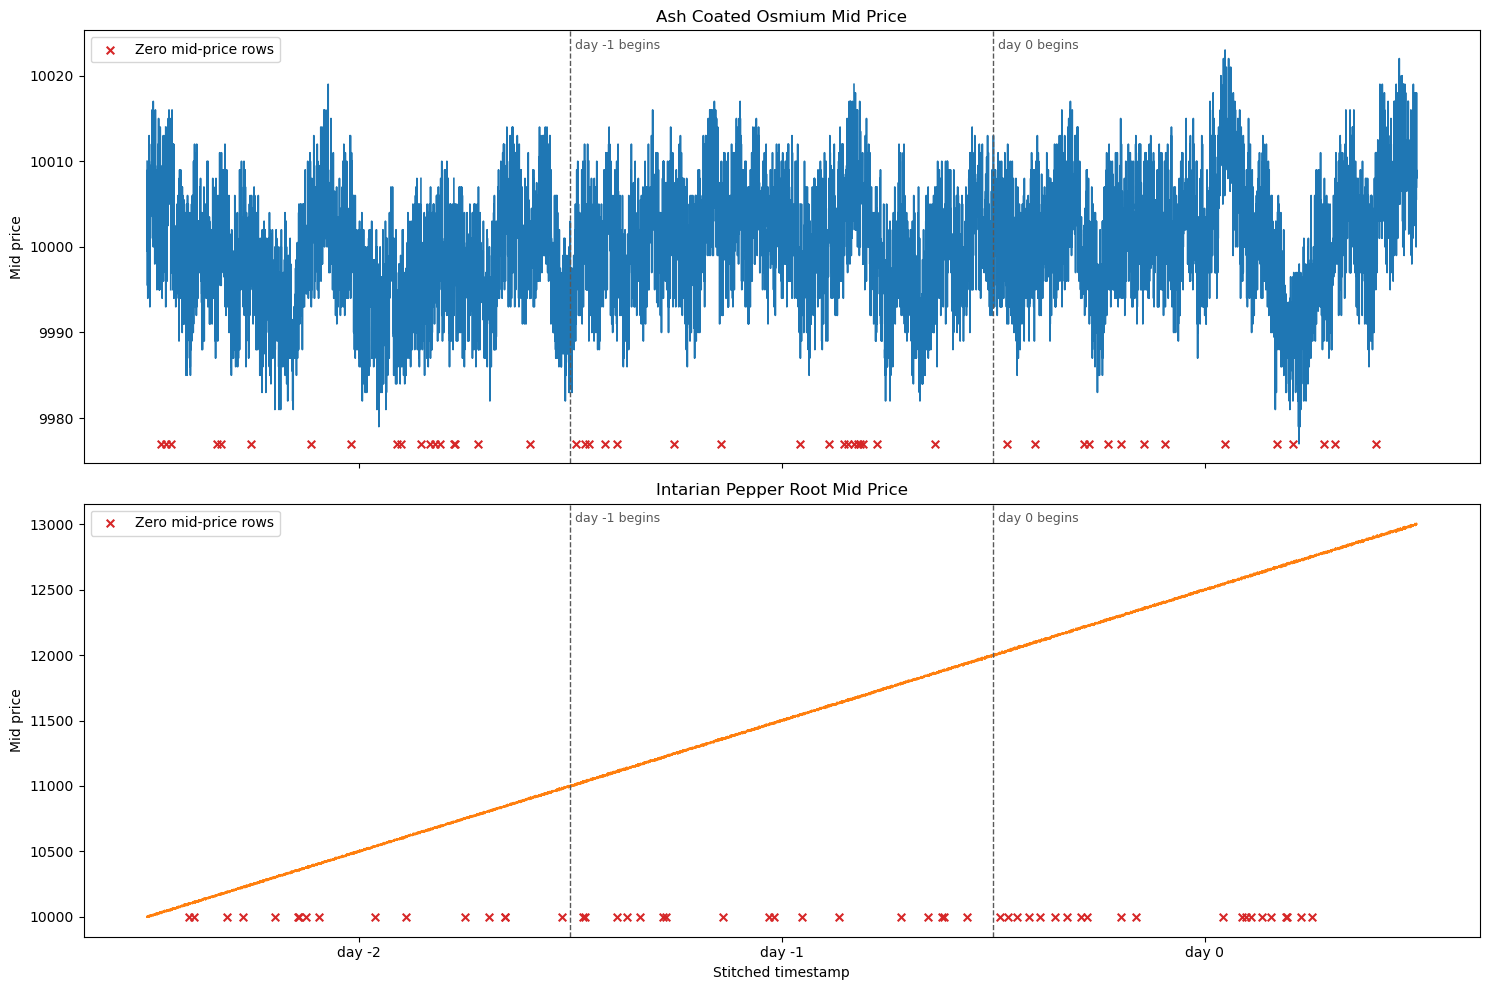

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for ax, product in zip(axes, PRODUCTS):
    frame = price_frames[product]
    ax.plot(
        frame["stitched_timestamp"],
        frame["clean_mid_price"],
        color=PRODUCT_COLORS[product],
        linewidth=1.2,
    )
    anomaly_points = frame.loc[frame["clean_mid_price"].isna(), ["stitched_timestamp"]]
    if not anomaly_points.empty:
        ax.scatter(
            anomaly_points["stitched_timestamp"],
            [frame["mid_price"].replace(0, pd.NA).dropna().min()] * len(anomaly_points),
            marker="x",
            color="#d62728",
            s=30,
            label="Zero mid-price rows",
        )
    ax.set_title(f"{PRODUCT_LABELS[product]} Mid Price")
    ax.set_ylabel("Mid price")
    add_day_markers(ax)
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Stitched timestamp")
plt.tight_layout()
plt.show()


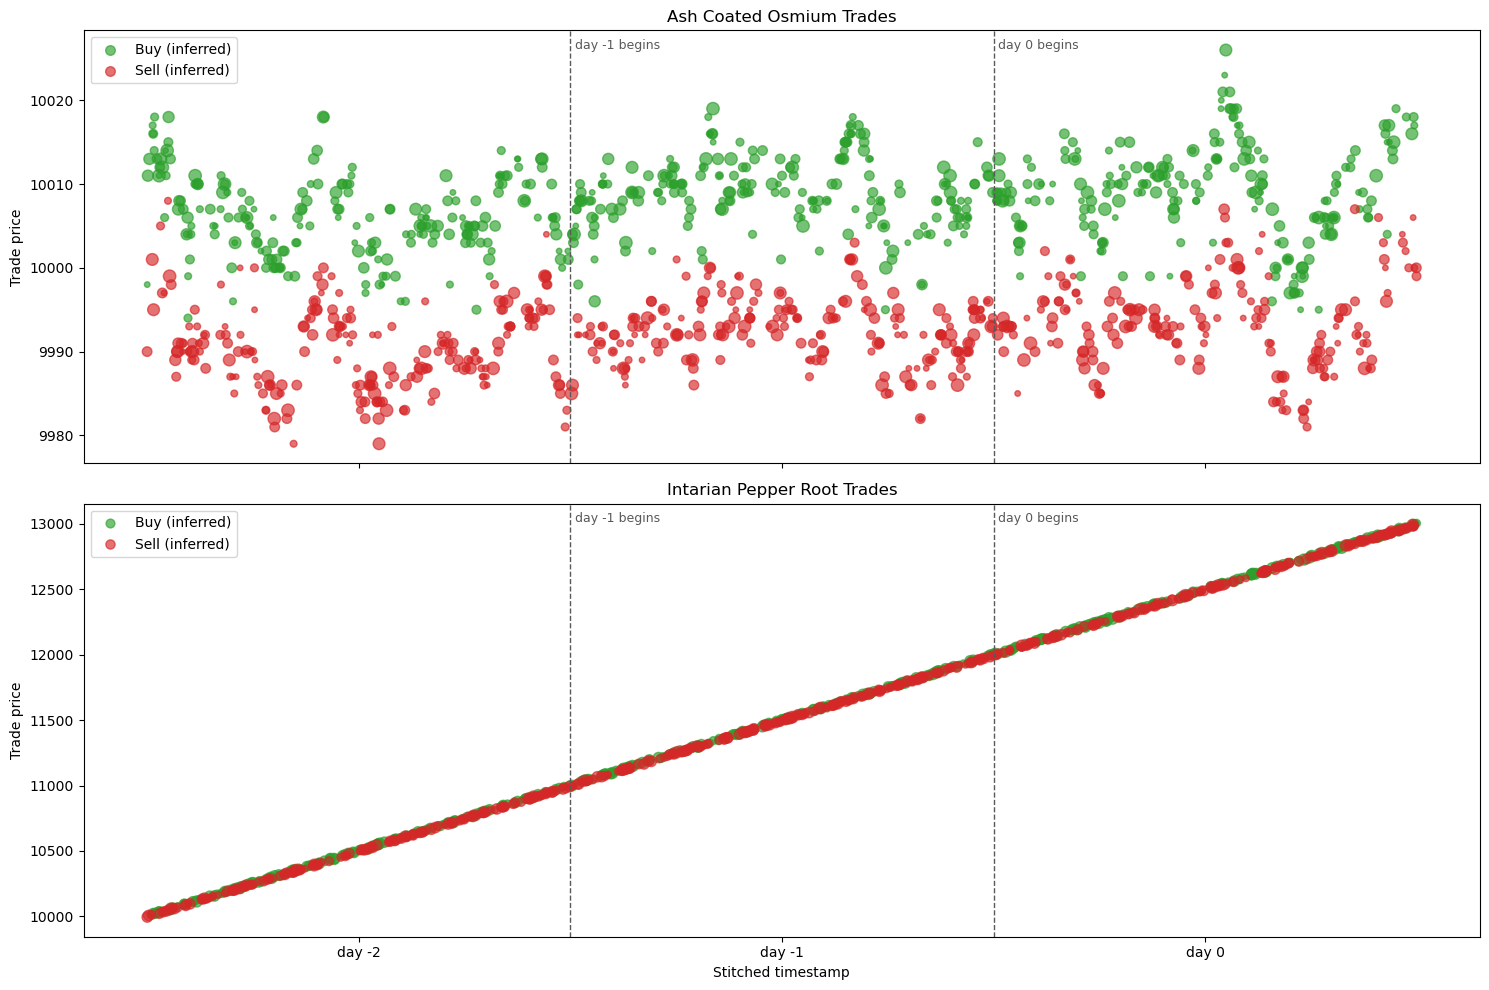

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for ax, product in zip(axes, PRODUCTS):
    frame = trade_frames[product]
    for side in ["Buy", "Sell", "Unknown"]:
        side_frame = frame.loc[frame["trade_side"] == side]
        if side_frame.empty:
            continue
        ax.scatter(
            side_frame["stitched_timestamp"],
            side_frame["price"],
            s=side_frame["quantity"] * 8,
            color=TRADE_SIDE_COLORS[side],
            alpha=0.65,
            label=f"{side} (inferred)",
        )
    ax.set_title(f"{PRODUCT_LABELS[product]} Trades")
    ax.set_ylabel("Trade price")
    add_day_markers(ax)
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Stitched timestamp")
plt.tight_layout()
plt.show()


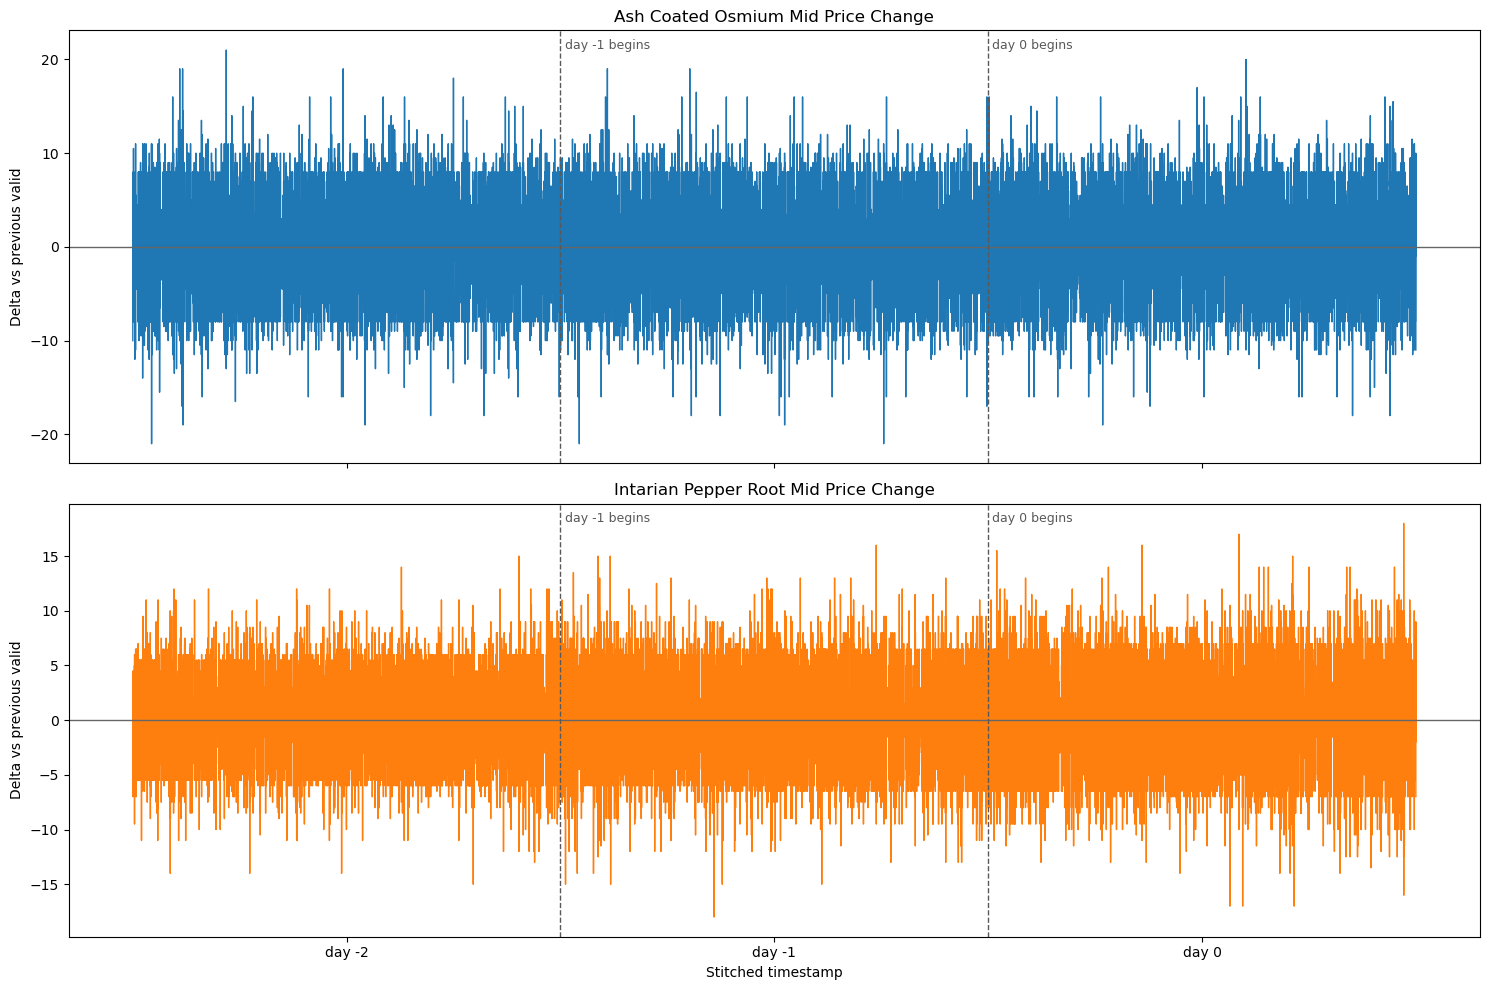

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for ax, product in zip(axes, PRODUCTS):
    frame = price_frames[product].dropna(subset=["clean_mid_price_change"])
    ax.plot(
        frame["stitched_timestamp"],
        frame["clean_mid_price_change"],
        color=PRODUCT_COLORS[product],
        linewidth=1.0,
    )
    ax.axhline(0, color="0.4", linewidth=1)
    ax.set_title(f"{PRODUCT_LABELS[product]} Mid Price Change")
    ax.set_ylabel("Delta vs previous valid")
    add_day_markers(ax)

axes[-1].set_xlabel("Stitched timestamp")
plt.tight_layout()
plt.show()


In [15]:
volatility_summary = pd.DataFrame(
    {
        "lookback_timestamps": ASH_OSMIUM_VOLATILITY_LOOKBACKS,
        "valid_points": [int(ash_prices[f"volatility_{lookback}"].notna().sum()) for lookback in ASH_OSMIUM_VOLATILITY_LOOKBACKS],
        "latest_volatility": [ash_prices[f"volatility_{lookback}"].dropna().iloc[-1] for lookback in ASH_OSMIUM_VOLATILITY_LOOKBACKS],
    }
)
volatility_summary


,lookback_timestamps,valid_points,latest_volatility
0,25,29927,8.551023
1,50,29902,8.506762
2,100,29852,8.915296
3,250,29702,8.660716


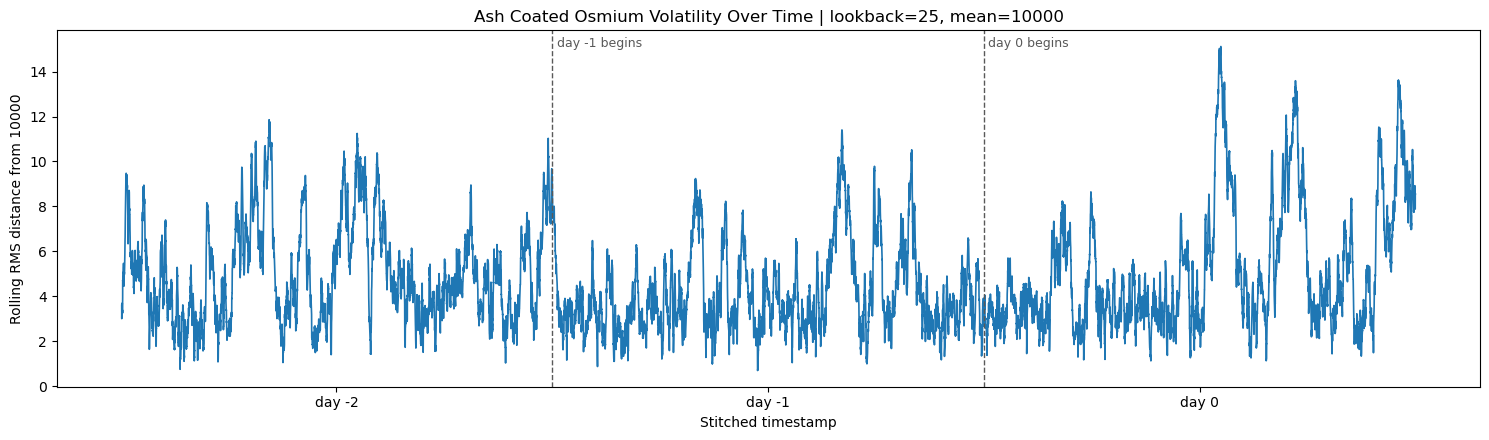

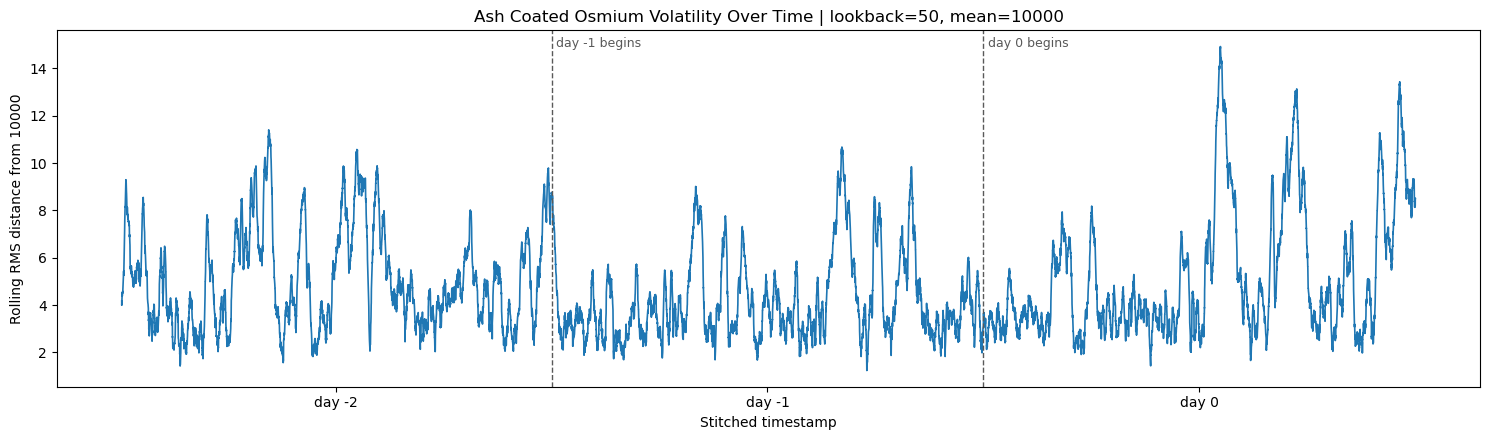

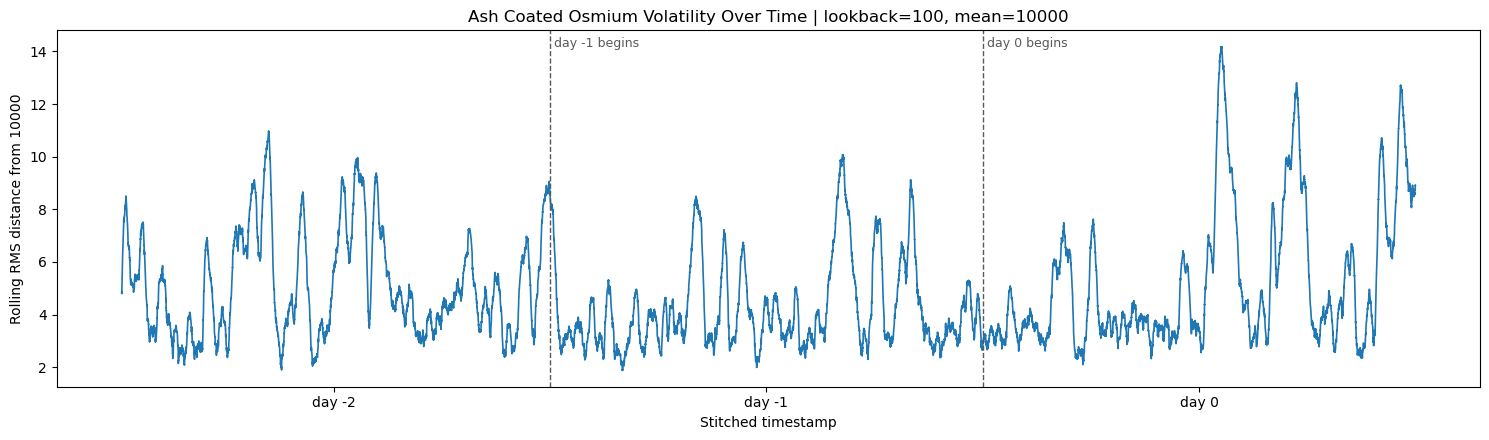

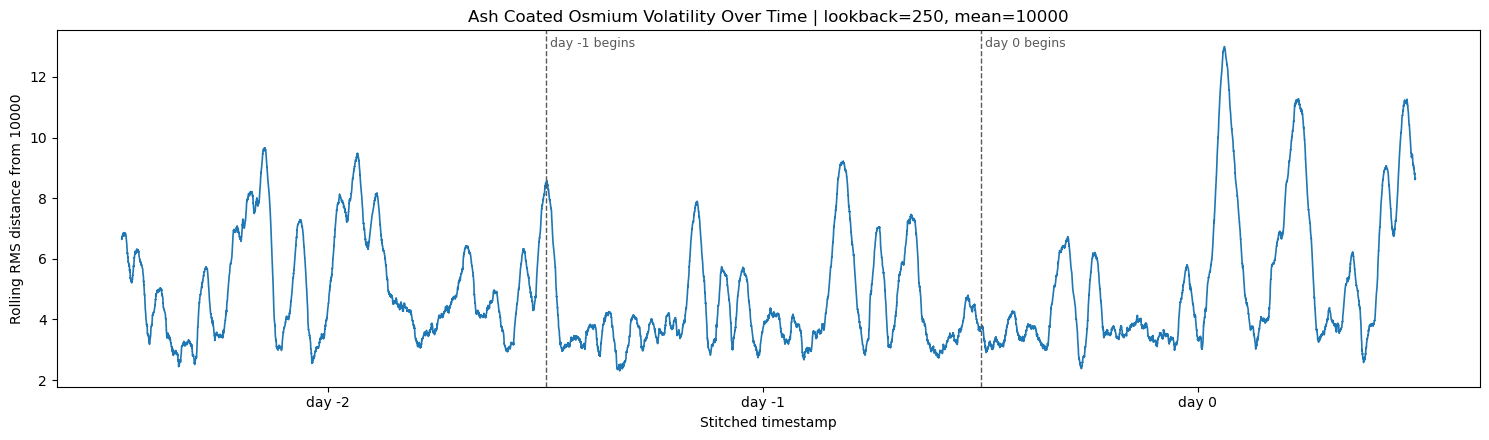

In [16]:
for lookback in ASH_OSMIUM_VOLATILITY_LOOKBACKS:
    fig, ax = plt.subplots(figsize=(15, 4.5))
    volatility_column = f"volatility_{lookback}"
    frame = ash_prices.dropna(subset=[volatility_column])

    ax.plot(
        frame["stitched_timestamp"],
        frame[volatility_column],
        color=PRODUCT_COLORS["ASH_COATED_OSMIUM"],
        linewidth=1.2,
    )
    ax.set_title(
        f"Ash Coated Osmium Volatility Over Time | lookback={lookback}, mean={ASH_OSMIUM_MEAN}"
    )
    ax.set_ylabel("Rolling RMS distance from 10000")
    ax.set_xlabel("Stitched timestamp")
    add_day_markers(ax)
    plt.tight_layout()
    plt.show()
